In [205]:
import pandas as pd ; import numpy as np ; import os ; from tqdm.auto import tqdm
import matplotlib.pyplot as plt ; from matplotlib.gridspec import GridSpec
import random ; import torch ; import joblib

# data preproccessing
from src.data_preprocessor_old import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from src.data_preprocessor_old import DataSorter
from src.transient_dataset_old import TransientDataset

from AppleCider.core.model import Informer, GalSpecNet, MetaModel, BTSModel, AstroM4

from datetime import datetime
import optuna 
from optuna.exceptions import DuplicatedStudyError
from math import sqrt
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import wandb
from torch.utils.data import Dataset
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau, LinearLR
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d 
from scipy import stats

In [207]:
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [208]:
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'
SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')

TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test_2-15'
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train_2-15'

In [209]:
## sort objects in dataset into train and test
## can filter out objects without spectra from SEDM
## this just saves a df with obj_id, classification
#test_df, train_df = DataSorter.sample_objects_from_df(SEDM_dataset, 'type', CLASSES, data_dir, n_test=1000, n_train=6000, sedm_spec_only=False, downsample_SNIa=False)
# i already saved these prior... 
test_df_215 = pd.read_csv('/Users/junell/Documents/AppleCider_Data/test_df_raw.csv')
train_df_215 = pd.read_csv('/Users/junell/Documents/AppleCider_Data/train_df_raw.csv')

CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']

In [5]:
## preprocess data time: 8:46, preprocess data: 0:54
dataset_test = TransientDataset(TEST_DATA_PATH, base_path=data_dir)
dataset_test.preprocess_data(test_df_215, data_dir)

dataset_test.preprocess_and_save()

In [6]:
## preprocess data time: 57:31, preprocess data: 8:01
dataset_train = TransientDataset(TRAIN_DATA_PATH, base_path=data_dir)
dataset_train.preprocess_data(train_df_215, data_dir)

dataset_train.preprocess_and_save()

In [7]:
data_test_215, data_train_215 = DataSorter.create_df_of_object_alerts_in_dataset(test_df_215, train_df_215, TEST_DATA_PATH, TRAIN_DATA_PATH)
data_test_215

In [8]:
id2target = {i: CLASSES[i] for i in range(10)}
target2id = {v: k for k, v in id2target.items()}

data_test_215['type_encoded'] = data_test_215['type'].map(target2id)
data_train_215['type_encoded'] = data_train_215['type'].map(target2id)

In [210]:
# already saved this prior so... just reading 
data_test_215 = pd.read_csv('/Users/junell/Documents/AppleCider_Data/data_test_2-15.csv')
data_train_215 = pd.read_csv('/Users/junell/Documents/AppleCider_Data/data_train_2-15.csv')
data_train_215

,name,file,type,type_encoded
0,ZTF17aaajnki,ZTF17aaajnki_alert_1.npy,AGN,4
1,ZTF17aaajnki,ZTF17aaajnki_alert_2.npy,AGN,4
2,ZTF17aaaobyl,ZTF17aaaobyl_alert_2.npy,Cataclysmic,3
3,ZTF17aaaobyl,ZTF17aaaobyl_alert_3.npy,Cataclysmic,3
4,ZTF17aaaukqn,ZTF17aaaukqn_alert_10.npy,Cataclysmic,3
...,...,...,...,...
28117,ZTF24abbrcrq,ZTF24abbrcrq_alert_6.npy,SN Ia,0
28118,ZTF24abbsboo,ZTF24abbsboo_alert_3.npy,SN Ia,0
28119,ZTF24abbsboo,ZTF24abbsboo_alert_4.npy,SN Ia,0
28120,ZTF24abbsboo,ZTF24abbsboo_alert_5.npy,SN Ia,0


end data preprocessing stuff
***

In [217]:
from torch import nn

class DataGenerator_notebook(torch.utils.data.Dataset):

    def __init__(self, preprocessed_path, df, step, file_list=None, **kwargs):
        super().__init__(**kwargs)
        self.preprocessed_path = preprocessed_path
        self.step = step
        self.df = df
        
        
        self.id2target = {i: x for i, x in enumerate(sorted(self.df[self.step].unique()))}
        self.target2id = {'SN Ia': 0 , 'SN Ic': 0,  'SN Ib': 0, 'SN II': 1, 'SN IIP': 1, 'SN IIn': 1, 'SN IIb': 1,
                          'Cataclysmic': 2, 'AGN': 3, 'Tidal Disruption Event': 4}

        if file_list is not None:
            self.data_files = file_list
        else:
            self.data_files = [f for f in os.listdir(preprocessed_path) if f.endswith('.npy')]
        
    def __len__(self): 
        return(len(self.data_files))
    
    def __getitem__(self, index):    
        ''' load processed object alerts to get photometry, metadata, images''' 
        file_path = os.path.join(self.preprocessed_path, str(self.data_files[index]))
        sample = np.load(file_path, allow_pickle=True).item()

        photometry = sample['photometry']
        metadata = sample['metadata'].to_numpy()
        images = sample['images']
        spectra = sample['spectra']

        # get spectra csv, save wavelengths fluxes
        obj_id_alert = str(self.data_files[index])
        obj_id = obj_id_alert[:12] # only includes ZTFID from 'ZTFID_alerts.npy' 
        
        # get label
        obj_df = self.df[self.df['name'] == obj_id]
        obj_label = obj_df['type_encoded'].iloc[0]
        
        # convert photometry, metadata, images, spectra to tensors
        photometry_tensor = torch.tensor(photometry, dtype=torch.float32)
        #padd tensors
        photo_len = len(photometry_tensor)
        max_photo = 225  # maximum photometry length from an alert
        add_dim = max_photo - photo_len
        
        # padded photometry so all photometry the same length
        if photo_len <= 225:
            photometry_padded = nn.ConstantPad1d((0, 0, 0, add_dim), 0)(photometry_tensor)
        else:
            # check max photo length from alerts again! 
            print("too much photometry. try again!", photo_len)
            
        photometry_mask = torch.ones((photometry_padded.size(0), photometry_padded.size(1)))    
            
        metadata_tensor = torch.tensor(metadata)
        images_tensor = torch.tensor(images)
        spectra_tensor = torch.from_numpy(spectra)
        # convert label to tensor
        target = torch.tensor(obj_label).type(torch.LongTensor)  
        
        # functionally these are blanks
        blank_spectra = torch.zeros((225, 4))
        blank_metadata = torch.zeros((225, 4))
        blank_images = torch.zeros((225, 4))

        return photometry_padded, photometry_mask, blank_metadata, blank_images, blank_spectra, target


In [212]:
test_files, _ = DataSorter.split_train_validation_files(data_test_215, 'type',100)
test_dataset = DataGenerator_notebook(TEST_DATA_PATH, data_test_215, 'type', file_list=train_files2)

In [218]:
train_files, val_files = DataSorter.split_train_validation_files(data_train_215, 'type')

train_dataset = DataGenerator_notebook(TRAIN_DATA_PATH, data_train_215, 'type', file_list=train_files)
val_dataset = DataGenerator_notebook(TRAIN_DATA_PATH, data_train_215, 'type', file_list=val_files)

In [ ]:
photometry, photometry_mask, _, _, _, target = train_dataset[9]
photometry.shape, photometry_mask.shape, target.shape,\
photometry.dtype, photometry_mask.dtype, target.dtype

In [220]:
def collate_fn_WORKS_PHOTO(data):
    photometry, _, _,_,_,labels = zip(*data)
    
    labels = torch.tensor(labels, dtype=torch.long)
    
    photometry = torch.stack(photometry)
    photometry_mask = torch.ones((photometry.size(0), photometry.size(1)))
    
    spectra = torch.zeros((len(data), 225))
    metadata = torch.zeros((len(data), 225))
    images = torch.zeros((len(data), 225))

    # works like this:
    return photometry, photometry_mask, _, _, _, labels

In [221]:
train_dataloader = DataLoader(train_dataset, batch_size=128, collate_fn = collate_fn_WORKS_PHOTO,
                              shuffle=True, drop_last=True)

val_dataloader = DataLoader(val_dataset, batch_size=128,collate_fn = collate_fn_WORKS_PHOTO,
                              shuffle=True)

In [222]:
test_dataloader = DataLoader(val_dataset, batch_size=128,collate_fn = collate_fn_WORKS_PHOTO)

In [224]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, _,_,_ target  = batch

In [225]:
photometry, photometry_mask, _, _, _, target  = batch
photometry.shape, photometry_mask.shape, target.shape,\
photometry.dtype, photometry_mask.dtype, target.dtype

(torch.Size([128, 225, 4]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128]),
 torch.float32,
 torch.float32,
 torch.int64)

In [226]:
config = {
    'project': 'AppleCider',
    'mode': 'photo',   
    'config_from': None,    
    'random_seed': 42,
    'use_wandb': True,
    'save_weights': True,
    'weights_path': f'/Users/junell/Documents/AppleCider/AppleCider/weights/photometry/',
    
    'use_pretrain': None, 'freeze': False, 'num_classes': len(CLASSES),

    # Photometry Model
    'seq_len': 225,
    'p_enc_in': 4,
    'p_d_model': 128,
    'p_dropout': 0.2,
    'p_factor': 1,
    'p_output_attention': False,
    'p_n_heads': 4,
    'p_d_ff': 200,
    'p_activation': 'gelu',
    'p_e_layers': 8,

    # Training
    'batch_size': 200,
    'lr': 0.001,
    'beta1': 0.9,
    'beta2': 0.999,
    'weight_decay': 0.01,
    'epochs': 8,   # when your laptop overheats
    'early_stopping_patience': 5,
    'factor': 0.3,  # for ReduceLROnPlateau scheduler
    'patience': 3,  # for ReduceLROnPlateau scheduler
    'warmup': True,
    'warmup_epochs': 10,
    'clip_grad': False,
    'clip_value': 5
}


In [227]:
#config = run.config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using', device)

model = Informer(config)
model = model.to(device)

Using cpu


In [228]:
model

Informer(
  (enc_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(4, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False, padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (attn_layers): ModuleList(
      (0): EncoderLayer(
        (attention): AttentionLayer(
          (inner_attention): ProbAttention(
            (dropout): Dropout(p=0.2, inplace=False)
          )
          (query_projection): Linear(in_features=128, out_features=128, bias=True)
          (key_projection): Linear(in_features=128, out_features=128, bias=True)
          (value_projection): Linear(in_features=128, out_features=128, bias=True)
          (out_projection): Linear(in_features=128, out_features=128, bias=True)
        )
        (conv1): Conv1d(128, 200, kernel_size=(1,), stride=(1,))
        (conv2): Conv1d(200, 128, kernel_size=(1,), stride=(1,))
        

In [229]:
with torch.no_grad():
    photometry, photometry_mask = photometry.to(device), photometry_mask.to(device)
    output = model(photometry, photometry_mask)

In [230]:
optimizer = Adam(model.parameters(), lr=config['lr'], betas=(config['beta1'], config['beta2']),
                 weight_decay=config['weight_decay'])
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=config['factor'], patience=config['patience'])
criterion = torch.nn.CrossEntropyLoss()

In [231]:
import numpy as np
import torch
import torch.nn.functional as F
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import wandb
import os
import optuna

from AppleCider.util.early_stopping import EarlyStopping

wandb.init(
    project=config['project'],
    config=config, group='AC',
    job_type='train')

class Trainer:
    def __init__(self, model, optimizer, scheduler, warmup_scheduler, criterion, device, config, trial=None):
        
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.warmup_scheduler = warmup_scheduler
        self.criterion = criterion
        self.device = device
        self.trial = trial

        self.mode = config['mode']
        self.save_weights = config['save_weights']
        self.weights_path = config['weights_path']
        self.use_wandb = config['use_wandb']
        self.early_stopping = EarlyStopping(patience=config['early_stopping_patience'])
        self.warmup_epochs = config['warmup_epochs']
        self.clip_grad = config['clip_grad']
        self.clip_value = config['clip_value']

        self.total_loss = []
        self.total_correct_predictions = 0
        self.total_predictions = 0

    def store_weights(self, epoch):
        torch.save(self.model.state_dict(), os.path.join(self.weights_path, f'weights-{datetime.now().strftime("%Y-%m-%d-%H-%M")}-{epoch}.pth'))
        torch.save(self.model.state_dict(), os.path.join(self.weights_path, f'weights-{datetime.now().strftime("%Y-%m-%d-%H-%M")}-best.pth'))

    def zero_stats(self):
        self.total_loss = []
        self.total_correct_predictions = 0
        self.total_predictions = 0

    # TODO update to 4 elements
    def update_stats_clip(self, loss, logits_ps, logits_sm, logits_mp):
        labels = torch.arange(logits_ps.shape[0], dtype=torch.int64, device=self.device)

        prob_ps = (F.softmax(logits_ps, dim=1) + F.softmax(logits_ps.transpose(-1, -2), dim=1)) / 2
        prob_sm = (F.softmax(logits_sm, dim=1) + F.softmax(logits_sm.transpose(-1, -2), dim=1)) / 2
        prob_mp = (F.softmax(logits_mp, dim=1) + F.softmax(logits_mp.transpose(-1, -2), dim=1)) / 2
        prob = (prob_ps + prob_sm + prob_mp) / 3

        _, pred_labels = torch.max(prob, dim=1)
        correct_predictions = (pred_labels == labels).sum().item()

        self.total_correct_predictions += correct_predictions
        self.total_predictions += labels.size(0)
        self.total_loss.append(loss.item())

    def update_stats(self, loss, logits, labels):
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        _, predicted_labels = torch.max(probabilities, dim=1)
        correct_predictions = (predicted_labels == labels).sum().item()

        self.total_correct_predictions += correct_predictions
        self.total_predictions += labels.size(0)
        self.total_loss.append(loss.item())

    def calculate_stats(self):
        return sum(self.total_loss) / len(self.total_loss), self.total_correct_predictions / self.total_predictions

    def get_logits(self, photometry, photometry_mask, metadata, images, spectra):
        
        if self.mode == 'photo':
            #print(photometry.shape)
            #print(photometry_mask.shape)
            logits = self.model(photometry, photometry_mask)
        elif self.mode == 'spectra':
            logits = self.model(spectra)
        elif self.mode == 'meta':
            logits = self.model(metadata)
        elif self.mode == 'image':
            logits = self.model(images)
        else:  # all 4 modalities
            logits = self.model(photometry, metadata, images, spectra)

        return logits

    # TODO Update to 4 elements
    def step_clip(self, photometry, photometry_mask, spectra, metadata):
        """Perform a training step for the CLIP pretraining model"""
        logits_ps, logits_sm, logits_mp = self.model(photometry, photometry_mask, spectra, metadata)
        
        loss_ps, loss_sm, loss_mp = self.criterion(logits_ps, logits_sm, logits_mp)
        loss = loss_ps + loss_sm + loss_mp

        self.update_stats_clip(loss, logits_ps, logits_sm, logits_mp)

        return loss, loss_ps, loss_sm, loss_mp

    def step(self, photometry, photometry_mask, metadata, images, spectra, labels):
        """Perform a training step for the classification model"""
        logits = self.get_logits(photometry, photometry_mask, metadata, images, spectra)    
        
        loss = self.criterion(logits, labels)

        self.update_stats(loss, logits, labels)

        return loss

    def get_gradient_norm(self):
        total_norm = 0.0

        for param in self.model.parameters():
            if param.grad is not None:
                param_norm = param.grad.data.norm(2)
                total_norm += param_norm.item() ** 2

        return total_norm ** 0.5

    def train_epoch(self, train_dataloader):
        self.model.train()
        self.zero_stats()
        
        for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(train_dataloader):
            photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
        
            metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)
            labels = labels.to(self.device)    
            

            self.optimizer.zero_grad()

            if self.mode == 'clip':
                # TODO add images
                loss, loss_ps, loss_sm, loss_mp = self.step_clip(photometry, photometry_mask, spectra, metadata)
                
                if self.use_wandb:
                    wandb.log({'step_loss': loss.item(), 'loss_ps': loss_ps.item(), 'loss_sm': loss_sm.item(),
                               'loss_mp': loss_mp.item()})
            else:
                loss = self.step(photometry, photometry_mask, metadata, images, spectra, labels)

                if self.use_wandb:
                    wandb.log({'step_loss': loss.item()})

            loss.backward()

            if self.use_wandb:
                grad_norm = self.get_gradient_norm()
                wandb.log({'grad_norm': grad_norm})

            if self.clip_grad:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_value)

                if self.use_wandb:
                    clip_grad_norm = self.get_gradient_norm()
                    wandb.log({'clip_grad_norm': clip_grad_norm})

            self.optimizer.step()

        loss, acc = self.calculate_stats()

        return loss, acc
   

    def val_epoch(self, val_dataloader):
        self.model.eval()
        self.zero_stats()

        with torch.no_grad():
            for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(val_dataloader):
                photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
                metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)
                labels = labels.to(self.device)

                if self.mode == 'clip':
                    self.step_clip(photometry, photometry_mask, spectra, metadata)
                else:
                    self.step(photometry, photometry_mask, metadata, images, spectra, labels)

        loss, acc = self.calculate_stats()

        return loss, acc
    

    def train(self, train_dataloader, val_dataloader, epochs):
        best_val_loss = np.inf
        best_val_acc = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_dataloader)
            val_loss, val_acc = self.val_epoch(val_dataloader)

            best_val_loss = min(val_loss, best_val_loss)

            if self.trial:
                self.trial.report(val_loss, epoch)

                if self.trial.should_prune():
                    print('Prune')
                    wandb.finish()
                    raise optuna.exceptions.TrialPruned()

            if self.warmup_scheduler and epoch < self.warmup_epochs:
                self.warmup_scheduler.step()
                current_lr = self.warmup_scheduler.get_last_lr()[0]
            else:
                self.scheduler.step(val_loss)
                current_lr = self.scheduler.get_last_lr()[0]

            if self.use_wandb:
                wandb.log({'train_loss': train_loss, 'val_loss': val_loss, 'train_acc': train_acc,
                           'val_acc': val_acc,'learning_rate': current_lr, 'epoch': epoch})

            if best_val_acc < val_acc:
                best_val_acc = val_acc

                if self.use_wandb:
                    wandb.log({'best_val_acc': best_val_acc})

                if self.save_weights:
                    self.store_weights(epoch)

            print(f'Epoch {epoch}: Train Loss {round(train_loss, 4)} \t Val Loss {round(val_loss, 4)} \t \
                    Train Acc {round(train_acc, 4)} \t Val Acc {round(val_acc, 4)}')

            if self.early_stopping.step(val_loss):
                print(f'Early stopping at epoch {epoch}')
                break

        return best_val_loss

    def evaluate(self, val_dataloader, id2target):
        self.model.eval()

        all_true_labels = []
        all_predicted_labels = []
        
        
        for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(val_dataloader):
            with torch.no_grad():
                photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
                metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)

                logits = self.get_logits(photometry, photometry_mask, metadata, images, spectra)
                probabilities = torch.nn.functional.softmax(logits, dim=1)
                _, predicted_labels = torch.max(probabilities, dim=1)

                all_true_labels.extend(labels.numpy())
                all_predicted_labels.extend(predicted_labels.cpu().numpy())

        conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)
        conf_matrix_percent = 100 * conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

        labels = [id2target[i] for i in range(len(conf_matrix))]
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

        # Plot absolute values confusion matrix
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title('Confusion Matrix - Absolute Values')

        # Plot percentage values confusion matrix
        sns.heatmap(conf_matrix_percent, annot=True, fmt='.0f', cmap='Blues', xticklabels=labels, yticklabels=labels,
                    ax=axes[1])
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_title('Confusion Matrix - Percentages')

        if self.use_wandb:
            wandb.log({'conf_matrix': wandb.Image(fig)})

        return conf_matrix

In [232]:
warmup_scheduler = LinearLR(optimizer, start_factor=1e-5, end_factor=1, total_iters=config['warmup_epochs'])

trainer = Trainer(model=model, optimizer=optimizer, scheduler=scheduler, warmup_scheduler=warmup_scheduler,
                  criterion=criterion, device=device, config=config)

# works until here
trainer.train(train_dataloader, val_dataloader, epochs=config['epochs'])

100%|███████████████████████████████████████████| 44/44 [01:47<00:00,  2.44s/it]


Epoch 0: Train Loss 2.7772 	 Val Loss 2.7562 	                     Train Acc 0.0343 	 Val Acc 0.043


100%|███████████████████████████████████████████| 44/44 [01:57<00:00,  2.67s/it]


Epoch 1: Train Loss 1.2766 	 Val Loss 1.1678 	                     Train Acc 0.7196 	 Val Acc 0.7234


100%|███████████████████████████████████████████| 44/44 [01:25<00:00,  1.95s/it]


...

100%|███████████████████████████████████████████| 44/44 [01:28<00:00,  2.02s/it]


Epoch 6: Train Loss 0.9448 	 Val Loss 1.033 	                     Train Acc 0.7423 	 Val Acc 0.7326


100%|███████████████████████████████████████████| 44/44 [01:35<00:00,  2.17s/it]

Epoch 7: Train Loss 0.9288 	 Val Loss 1.0304 	                     Train Acc 0.7443 	 Val Acc 0.7377


1.0304488702253862

100%|███████████████████████████████████████████| 45/45 [01:47<00:00,  2.40s/it]


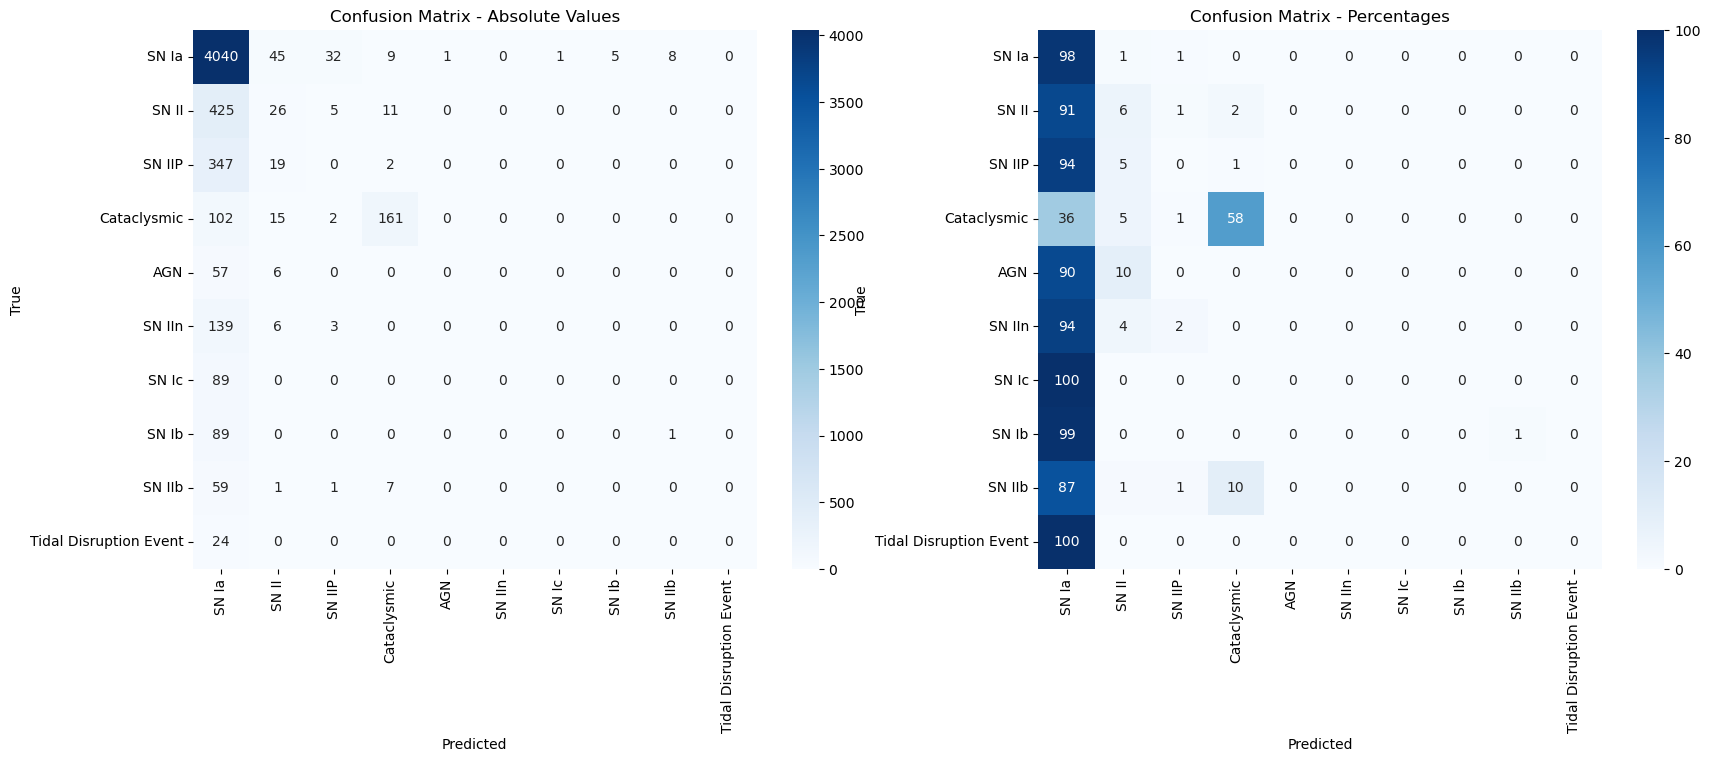

In [247]:
conf_matrix = trainer.evaluate(test_dataloader, id2target={0: 'SN Ia', 1: 'SN II',2: 'SN IIP', 3: 'Cataclysmic', 4: 'AGN',  5: 'SN IIn', 6: 'SN Ic',7: 'SN Ib', 8: 'SN IIb', 9: 'Tidal Disruption Event'})